# **NeurIPS 2025 Best Paper Awards (Part 2)**

For this coding tutorial, we will try to replicate the experiments and results from the papers:

* '1000 Layer Networks for Self-Supervised RL'
* 'Why Diffusion Models Don't Memorize'

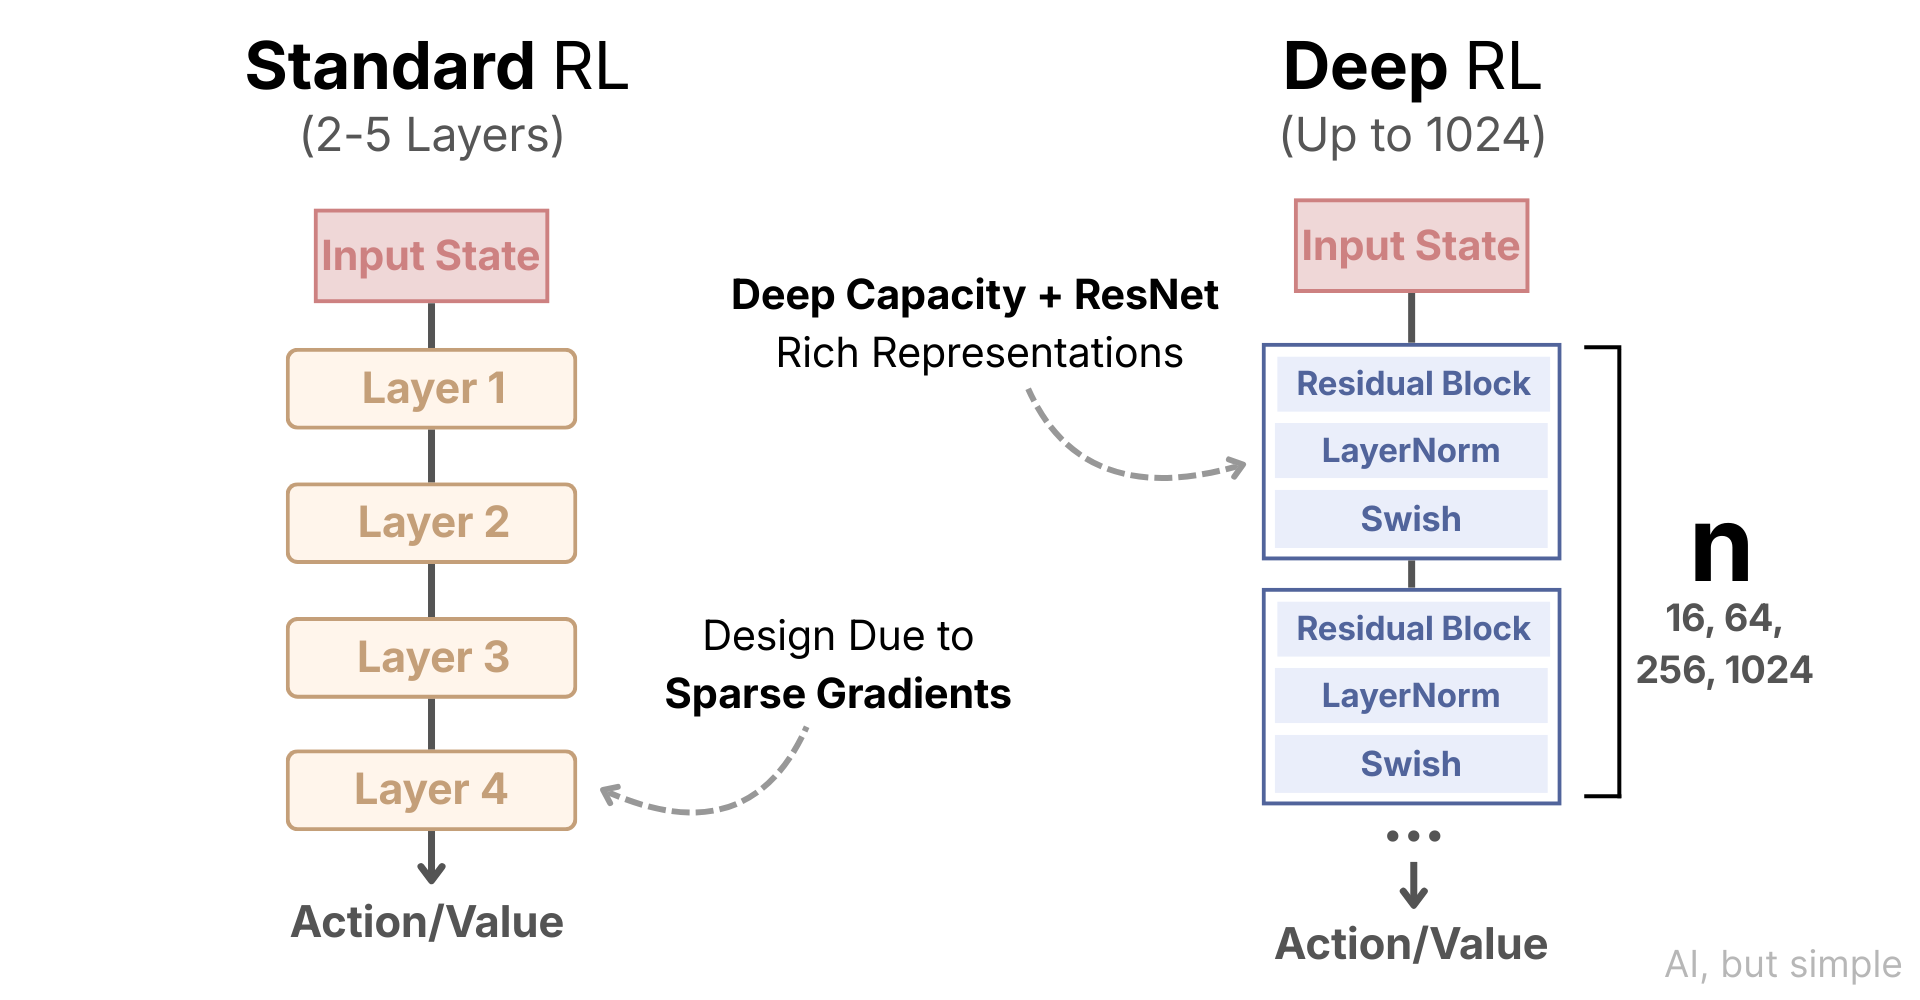

In order to do this, we will try to build and train minimal models based on both the above mentioned NeurIPS papers.

Please select the GPU in the runtime options. The code will have comments and explanations for clarity. Happy Learning!

—AI, But Simple Team

### **1000 Layer Networks for Self-Supervised RL** ###

**Paper:** *1000 Layer Networks for Self-Supervised RL*
(Wang, Javali, Bortkiewicz et al.,  Princeton / Warsaw - Best Paper)

For this paper, we will implement a minimal CRL agent with adjustable depth.

This paper studies very deep networks trained with contrastive RL (CRL) using an InfoNCE loss.

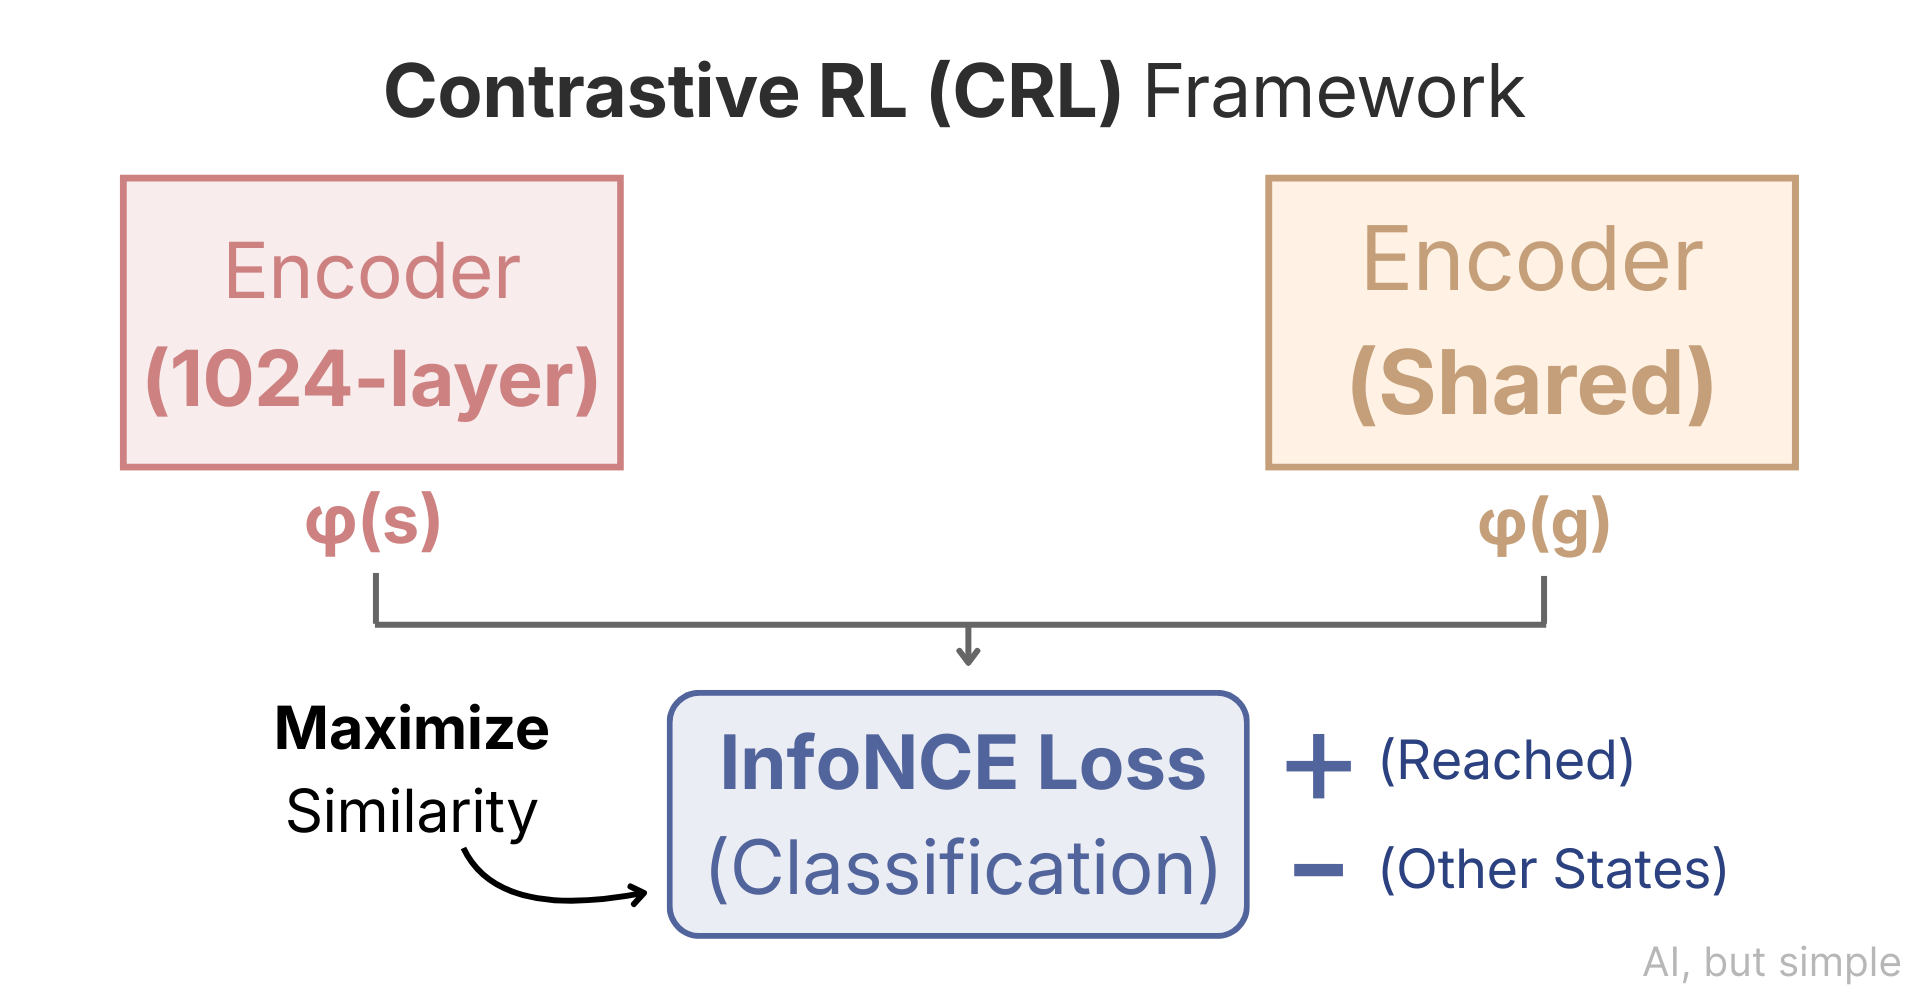

The key **ingredients**:
* Goal-conditined policy
* InfoNCE contrastive loss
* Residual blocks
* LyerNorm
* Swish (SiLU)
* Extreme depth (hundreds of layers)

We will build a minimal goal-conditioned contrastive RL setup. The environment is a simple 2D navigation world. The objective is to reach our randomly sampled goal. The learning method is using InfoNCE classification style loss.

Finally, our architecture consists of shallow and deep residual networks to show the difference between the two.

We will measure these metrics:
* contrastive loss
* representation quality
* goal discrimination accuracy

**First, let's import and install our key libraries:**
* `torch` as our deep learning framework
* `matplotlib` for plots and visualization
* `gymnasium` as our RL toolkit
* `numpy` for numerical operations

In [ ]:
!pip install torch gymnasium matplotlib

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gymnasium as gym
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

Now, we create a simple 2D goal environment, a tiny navigation world:

In [ ]:
class PointEnv:
    def __init__(self):
        self.reset()

    def reset(self):
        self.state = np.random.uniform(-1, 1, size=2)
        self.goal = np.random.uniform(-1, 1, size=2)
        return self.state, self.goal

    def step(self, action):
        self.state += action
        self.state = np.clip(self.state, -1, 1)
        done = False
        return self.state, done


### **Deep Residual Encoder** ###

Next, we build a Deep Residual Encoder, this is the key architectural part from the paper:

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fc = nn.Linear(dim, dim)
        self.act = nn.SiLU()

    def forward(self, x):
        return x + self.fc(self.act(self.norm(x)))


class GoalEncoder(nn.Module):
    def __init__(self, depth=4, hidden=256):
        super().__init__()
        self.input = nn.Linear(2, hidden)
        self.blocks = nn.Sequential(
            *[ResidualBlock(hidden) for _ in range(depth)]
        )
        self.output = nn.Linear(hidden, hidden)

    def forward(self, x):
        x = self.input(x)
        x = self.blocks(x)
        return self.output(x)

### **InfoNCE Loss** ###

This is the CRL objective.

In [ ]:
def info_nce(z_s, z_g, temperature=0.1):
    z_s = F.normalize(z_s, dim=-1)
    z_g = F.normalize(z_g, dim=-1)

    logits = z_s @ z_g.T / temperature
    labels = torch.arange(len(z_s)).to(device)

    return F.cross_entropy(logits, labels)

### **Collect Goal-Reaching Data** ###

We collect random transitions.

In [ ]:
def collect_batch(env, batch_size=256):
    states = []
    goals = []

    for _ in range(batch_size):
        s, g = env.reset()
        states.append(s)
        goals.append(g)

    return torch.tensor(states, dtype=torch.float32).to(device), \
           torch.tensor(goals, dtype=torch.float32).to(device)

### **Training Function** ###

In [ ]:
def train(depth, steps=2000):
    env = PointEnv()
    encoder = GoalEncoder(depth=depth).to(device)
    opt = torch.optim.Adam(encoder.parameters(), lr=3e-4)

    losses = []

    for step in range(steps):
        states, goals = collect_batch(env)

        z_s = encoder(states)
        z_g = encoder(goals)

        loss = info_nce(z_s, z_g)

        opt.zero_grad()
        loss.backward()
        opt.step()

        losses.append(loss.item())

        if step % 200 == 0:
            print(f"Depth {depth} | Step {step} | Loss {loss.item():.4f}")

    return losses


### **Train & Compare Shallow vs Deep Networks** ###

In [ ]:
loss_shallow = train(depth=4)
loss_deep = train(depth=64)

In [ ]:
plt.figure()
plt.plot(loss_shallow, label="Depth 4")
plt.plot(loss_deep, label="Depth 64")
plt.legend()
plt.title("Contrastive Loss vs Depth")
plt.show()

**We observe that a Deep Residual Network:**
* Learns better
* Achieves lower loss
* Better seperation of goals

The paper shows that in standard RL depth doesn't help but with a Contrastive RL with an InfoNCE objective, depth helps massively. A classification-style loss makes extreme depth trainable in RL.

### **Why Diffusion Models Don't Memorize** ###

**Paper:** *Why Diffusion Models Don't Memorize: The Role of Implicit Dynamical Regularization in Training*
(Bonnaire, Urfin, Biroli & Mézard, École Normale Supérieure / Bocconi - Best Paper)

Quoting from the paper, "In diffusion training, generalisation happens early, and memorization happens much later, and the memorization time grows with dataset size".

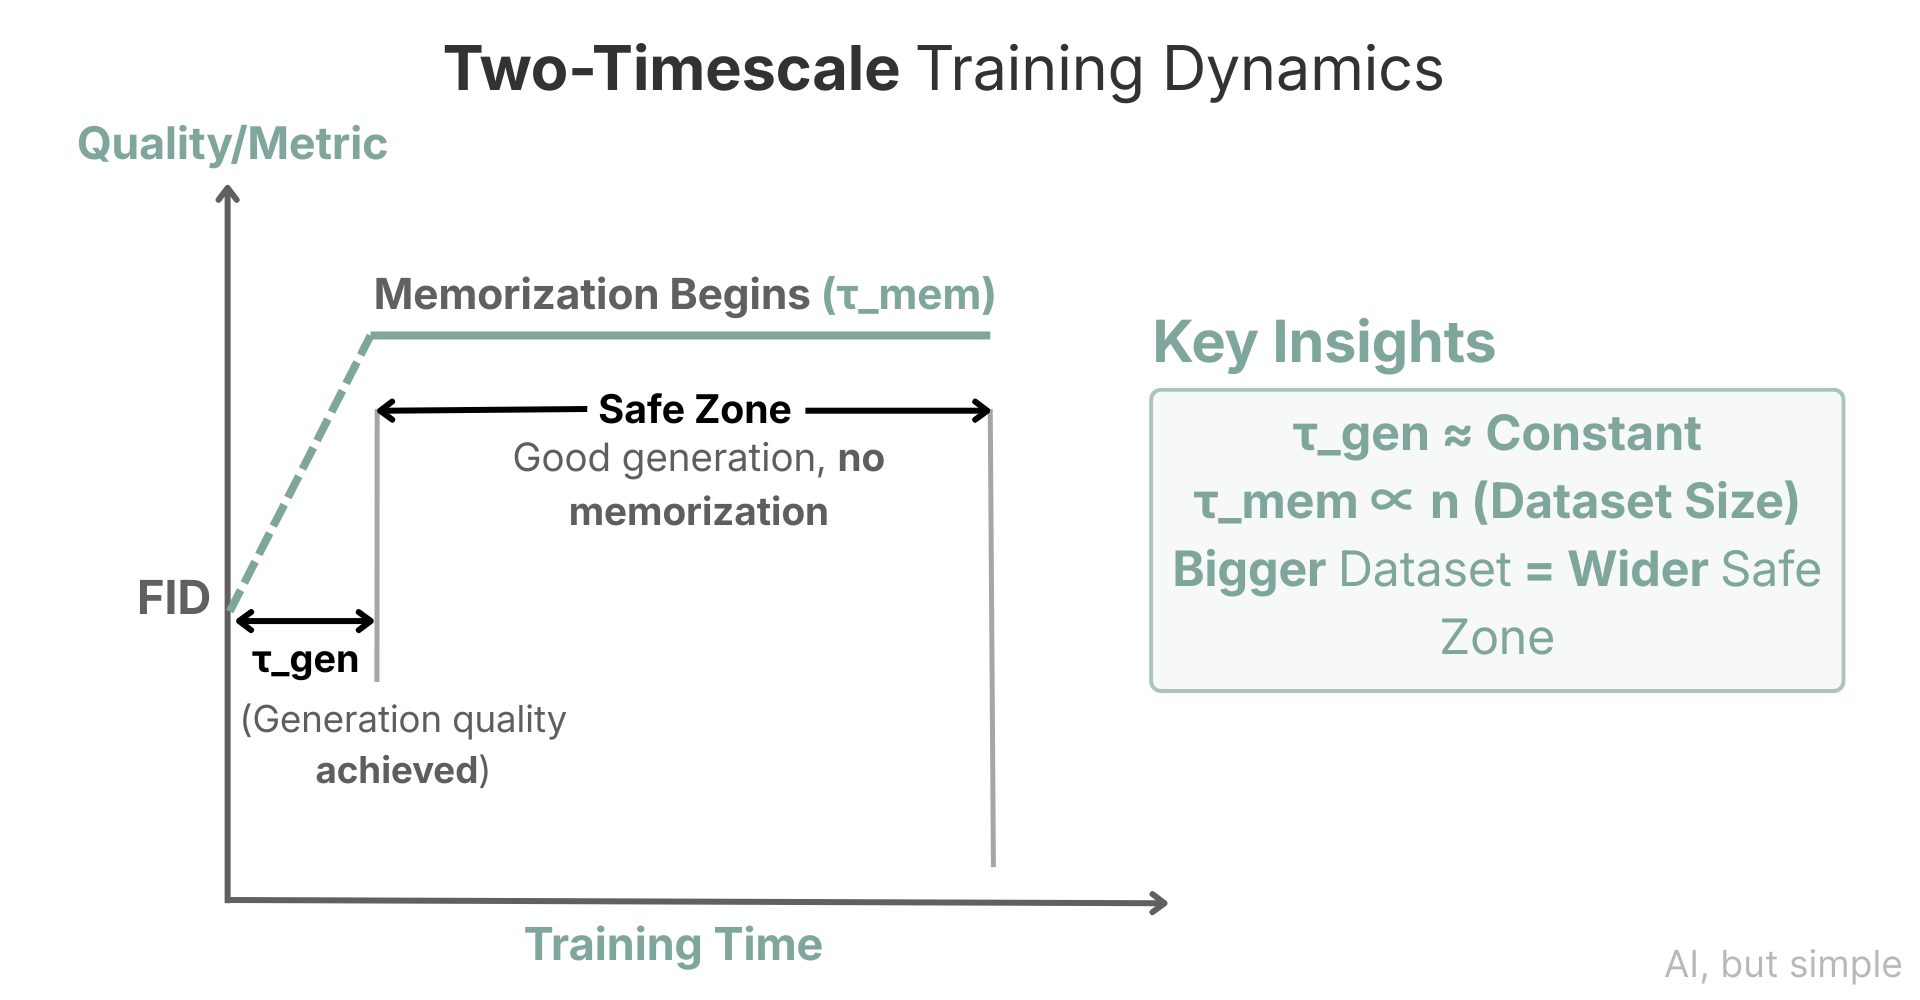

Hence to demonstrate this, the goals of this tutorial will be to:
* Train a small diffusion model
* Track: Training loss and memorization fraction
* Compare small vs large dataset
* Show memorization starts later for larger datasets

The key idea behind this experiment:

We measure memorization by looking at "How often is a generated sample extremely close to a training sample?"

If this fraction rises sharply, that means memorization has started.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

device = "cuda" if torch.cuda.is_available() else "cpu"

### **Build a Small Diffusion Model** ###

In [ ]:
class DiffusionMLP(nn.Module):
    def __init__(self, dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, dim)
        )

    def forward(self, x, t):
        t = t.unsqueeze(-1)
        return self.net(torch.cat([x, t], dim=-1))

### **Noise Schedule** ###

In [ ]:
def add_noise(x, t):
    t = t.unsqueeze(-1)
    noise = torch.randn_like(x)
    alpha = torch.exp(-t)
    noisy = alpha * x + torch.sqrt(1 - alpha**2) * noise
    return noisy, noise

### **Memorization Metric** ###

This checks if generated samples are too close to training samples.

In [ ]:
def memorisation_fraction(model, data, threshold=0.05, n_samples=256):
    model.eval()
    with torch.no_grad():
        x = torch.randn(n_samples, data.shape[1]).to(device)
        t = torch.rand(n_samples).to(device)
        pred_noise = model(x, t)
        x_denoised = x - pred_noise  # simple reverse step

        distances = torch.cdist(x_denoised, data)
        min_dist = distances.min(dim=1)[0]
        frac = (min_dist < threshold).float().mean().item()

    model.train()
    return frac

### **Training Function** ###

In [ ]:
def train_diffusion(dataset_size, steps=4000):
    dim = 2
    data = torch.randn(dataset_size, dim).to(device)

    model = DiffusionMLP(dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    losses = []
    mems = []

    for step in range(steps):
        idx = torch.randint(0, dataset_size, (128,))
        x = data[idx]

        t = torch.rand(128).to(device)
        noisy, noise = add_noise(x, t)

        pred = model(noisy, t)
        loss = F.mse_loss(pred, noise)

        opt.zero_grad()
        loss.backward()
        opt.step()

        losses.append(loss.item())

        if step % 200 == 0:
            mem = memorisation_fraction(model, data)
            mems.append(mem)
            print(f"Step {step} | Loss {loss.item():.4f} | Memorisation {mem:.3f}")

    return losses, mems

### **Running Two Experiments** ###

In [ ]:
print("Small dataset")
loss_small, mem_small = train_diffusion(dataset_size=128)

print("\nLarge dataset")
loss_large, mem_large = train_diffusion(dataset_size=2048)

In [ ]:
plt.figure()
plt.plot(mem_small, label="Small dataset (128)")
plt.plot(mem_large, label="Large dataset (2048)")
plt.legend()
plt.title("Memorisation Fraction Over Time")
plt.xlabel("Checkpoint (every 200 steps)")
plt.ylabel("Memorisation fraction")
plt.show()

**We observe that Both datasets generalize early, i.e. the loss drops quickly.**

Small dataset:
* Memorization rises earlier

Large dataset:
* Memorization rises much later

This shift reproduces what is discussed in the paper:
$$t_{mem} ∝ n$$

